# SAHI + RT-DETR 小物検出・カウント

通常推論と重複タイル推論を比較し、SAHI が統合した検出結果をクラス別に数えます。

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
from PIL import Image, ImageDraw
from sahi import AutoDetectionModel
from sahi.predict import get_prediction, get_sliced_prediction

MODEL_ID = 'PekingU/rtdetr_r101vd'
IMAGE_PATH = Path('../assets/test1.png')
CONFIDENCE_THRESHOLD = 0.30
SLICE_HEIGHT = 640
SLICE_WIDTH = 640
OVERLAP_HEIGHT_RATIO = 0.20
OVERLAP_WIDTH_RATIO = 0.20
DEVICE = 'cuda:0' if torch.cuda.is_available() else 'cpu'

if not IMAGE_PATH.is_file():
    raise FileNotFoundError(f'入力画像が見つかりません: {IMAGE_PATH}')

print(f'推論デバイス: {DEVICE}')
print(f'タイル: {SLICE_WIDTH} x {SLICE_HEIGHT}, 重なり: {OVERLAP_WIDTH_RATIO:.0%}')

推論デバイス: cuda:0
タイル: 640 x 640, 重なり: 20%


In [2]:
detection_model = AutoDetectionModel.from_pretrained(
    model_type='huggingface',
    model_path=MODEL_ID,
    confidence_threshold=CONFIDENCE_THRESHOLD,
    device=DEVICE,
)

normal_result = get_prediction(str(IMAGE_PATH), detection_model)
sliced_result = get_sliced_prediction(
    str(IMAGE_PATH),
    detection_model,
    slice_height=SLICE_HEIGHT,
    slice_width=SLICE_WIDTH,
    overlap_height_ratio=OVERLAP_HEIGHT_RATIO,
    overlap_width_ratio=OVERLAP_WIDTH_RATIO,
    postprocess_type='GREEDYNMM',
    postprocess_match_metric='IOS',
    postprocess_match_threshold=0.5,
    verbose=1,
)

print(f'通常推論の検出数: {len(normal_result.object_prediction_list)}')
print(f'タイル推論・統合後の検出数: {len(sliced_result.object_prediction_list)}')

/home/tadashi/develop/blog-experiments/object-detection/sahi-rtdetr-counting/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Performing prediction on 6 slices.
通常推論の検出数: 38
タイル推論・統合後の検出数: 45


In [3]:
def to_dataframe(predictions):
    rows = []
    for prediction in predictions:
        x1, y1, x2, y2 = (round(value, 1) for value in prediction.bbox.to_xyxy())
        rows.append({
            'class': prediction.category.name,
            'confidence': round(prediction.score.value, 3),
            'bbox': [x1, y1, x2, y2],
        })
    return pd.DataFrame(rows, columns=['class', 'confidence', 'bbox'])

normal_details = to_dataframe(normal_result.object_prediction_list)
sliced_details = to_dataframe(sliced_result.object_prediction_list)
comparison = pd.DataFrame({
    '推論方法': ['通常推論', 'SAHI タイル推論（統合後）'],
    '検出数': [len(normal_details), len(sliced_details)],
})

display(comparison)
print('以下の集計は、タイル境界の重複候補を統合した SAHI の結果だけを使用します。')

,推論方法,検出数
0,通常推論,38
1,SAHI タイル推論（統合後）,45


以下の集計は、タイル境界の重複候補を統合した SAHI の結果だけを使用します。


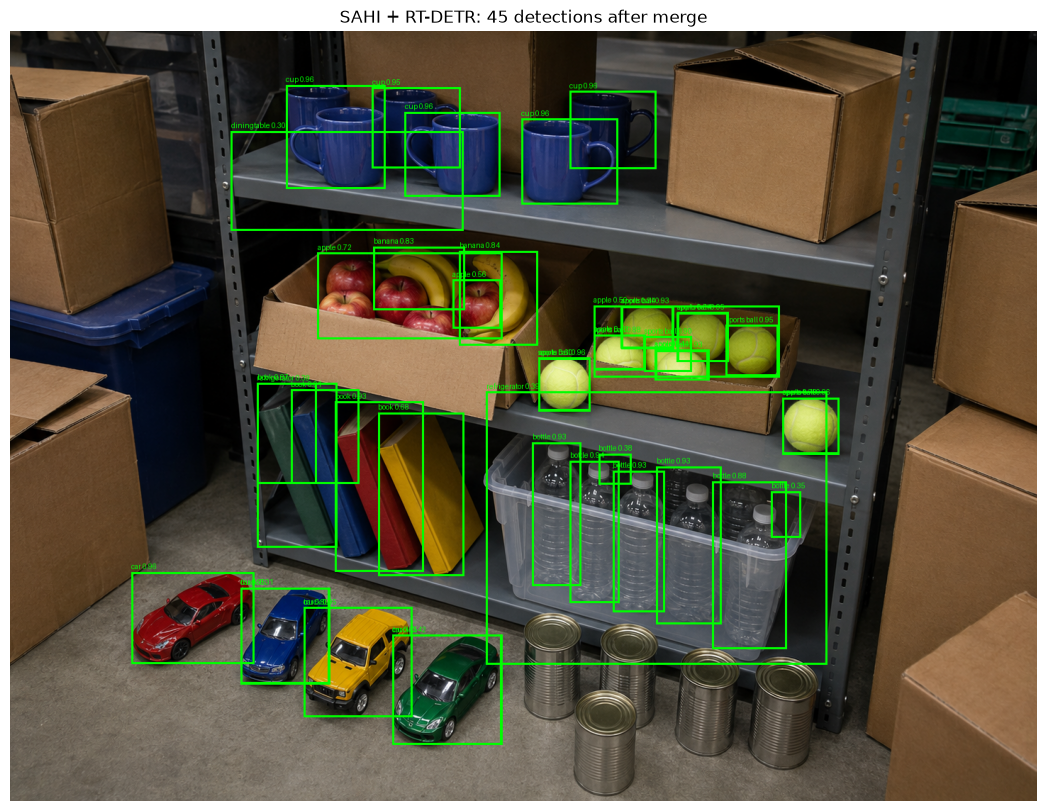

In [4]:
image = Image.open(IMAGE_PATH).convert('RGB')
annotated = image.copy()
draw = ImageDraw.Draw(annotated)
for detection in sliced_details.to_dict('records'):
    x1, y1, x2, y2 = detection['bbox']
    draw.rectangle((x1, y1, x2, y2), outline='lime', width=3)
    draw.text((x1, max(0, y1 - 14)), f"{detection['class']} {detection['confidence']:.2f}", fill='lime')

plt.figure(figsize=(14, 10))
plt.imshow(annotated)
plt.axis('off')
plt.title(f'SAHI + RT-DETR: {len(sliced_details)} detections after merge')
plt.show()

In [5]:
counts = (
    sliced_details.groupby('class').size().reset_index(name='検出数').sort_values('検出数', ascending=False)
    if not sliced_details.empty else pd.DataFrame(columns=['class', '検出数'])
)

print('### SAHI タイル推論（統合後）のクラス別検出数')
display(counts.rename(columns={'class': 'クラス'}))
print(f'合計: {len(sliced_details)} 個')
print('### 検出詳細')
display(sliced_details)

### SAHI タイル推論（統合後）のクラス別検出数


,クラス,検出数
0,apple,9
8,sports ball,8
3,bottle,7
5,cup,5
4,car,4
2,book,4
9,truck,3
1,banana,2
7,refrigerator,2
6,diningtable,1


合計: 45 個
### 検出詳細


,class,confidence,bbox
0,car,0.960,"[171.4, 763.4, 344.7, 892.6]"
1,car,0.951,"[539.4, 851.9, 693.6, 1006.2]"
2,car,0.949,"[325.0, 785.0, 451.4, 921.3]"
3,car,0.890,"[414.1, 812.9, 567.7, 967.1]"
4,truck,0.954,"[414.4, 812.6, 567.2, 967.1]"
5,truck,0.418,"[539.8, 851.7, 694.4, 1006.7]"
6,truck,0.311,"[325.0, 785.0, 450.5, 920.8]"
7,sports ball,0.961,"[1089.7, 517.4, 1169.6, 596.7]"
8,sports ball,0.956,"[745.3, 461.5, 818.8, 535.6]"
9,sports ball,0.951,"[1009.8, 414.7, 1083.8, 486.1]"
